# From Cross-Validation to SURE — numerical experiments

This notebook validates the paper's key asymptotic approximations and shows that
the risk of a CV-tuned regularized estimator converges to the SURE-tuned limit.
It is a thin front-end over the companion modules: the science lives in
`cvsure_sim.py`, and the configuration, sweep, and figure/table rendering live in
`run_all.py`. Running `python run_parallel.py` reproduces every artifact in
`output/`; this notebook displays those artifacts and explains them.

**What each result predicts, and how we measure it.** Every diagnostic is
scale-free and should shrink (or converge) as the sample size $n$ grows. We use
the same notation as the paper.

| Result | Claim | Diagnostic |
|---|---|---|
| **Lemma 2** | influence-function approx. $\hat\theta_n\approx\tilde\theta_n$ | $\Delta_{\mathrm{IF}}=\dfrac{E\lVert\hat\theta_n-\tilde\theta_n\rVert^2}{E\lVert\hat\theta_n-\theta_0\rVert^2}$ |
| **Lemma 4** | $n$-fold CV $\approx$ SURE, uniformly in $\lambda$ | $\Delta_{\mathrm{CV}}=\dfrac{E\,\sup_\lambda\lvert(CV_n(\lambda)-CV_n(\lambda_{\text{ref}}))-(SURE(\lambda)-SURE(\lambda_{\text{ref}}))\rvert}{E\,\mathrm{range}_\lambda\,SURE}$ |
| **Lemma 5** | $\arg\min CV \approx \arg\min SURE$ | $\Delta_{\mathrm{tune}}=\dfrac{E\lvert\,\text{loss}(\lambda^{CV})-\text{loss}(\lambda^{SURE})\rvert}{E\,\text{loss}(\lambda^{SURE})}$ |
| **Theorem 1 / Cor. 2** | risk convergence | $\Delta_{R}=\lvert R_n-R\rvert$, with $R_n=E[\min(\bar L_n,M)]$ |

In the code these are the columns `Delta_IF`, `Delta_CV`, `Delta_tune`, and
`R_n` / `R` / `Delta_R`.

**Modelling choices that keep the experiments faithful and simple.**

* All five designs live in the normalized coordinates of Assumption 2 (limiting
  Hessian $H=I$) with score variance $\Sigma=I$, in dimension $p=10$. Anisotropy
  is carried by the penalty matrix $A$: design **D5** is an anisotropic Ridge
  problem with a wide (geometric, $1$–$40$) eigenvalue spread, which stresses the
  tuning step by making $SURE$ poorly separated near its minimum.
* $\Sigma$ and $\theta_0$ are **known** (we control the data-generating process),
  so SURE uses the true $\Sigma$ and the influence function uses the true
  $\theta_0$. This isolates the approximation each lemma claims.

> **Normalization note.** Following the manuscript, $SURE$ carries an overall
> factor $\tfrac12$,
> $SURE=\tfrac12\big[\operatorname{trace}\Sigma+\lVert g^\lambda\rVert^2+2\operatorname{trace}(\nabla g^\lambda\Sigma)\big]$,
> so that it is an unbiased estimate of the risk
> $E[\tfrac12\lVert\theta^\lambda-\theta_0\rVert^2]$ — the same (loss) scale as the
> paper's loss and risk (Lemma 3 and Theorem 1: $\bar L=\tfrac12\lVert\cdot\rVert^2$)
> and as $n$-fold CV, which estimates out-of-sample loss. CV is therefore compared
> to $SURE$ directly; recentering at a reference $\lambda$ absorbs the $\Omega(n)$
> constant $c_n$, which is what makes $\Delta_{\mathrm{CV}}\to0$ below.

## 1. Setup

`cvsure_sim.py` holds the penalties (`Ridge`, `Lasso`), models (`LinearModel`,
`LogitModel`), the SURE formula, the leave-one-out CV, the limit experiment, and
the per-replication metrics. `run_all.py` holds the configuration `CFG`, the
sweep, and the renderers. To **switch designs**, edit `make_designs()` in
`cvsure_sim.py`.

In [1]:
import json, os
import numpy as np
import pandas as pd
import cvsure_sim as S
import run_all as R
from IPython.display import Image, display

OUTDIR = "output"

## 2. (Re)compute

`RECOMPUTE = False` simply loads the committed results in `output/results.json`.
Set `RECOMPUTE = True` to regenerate everything via `run_parallel.py` (replication
counts come from `run_all.CFG`; the leave-one-out designs D2–D4 are the expensive
part).

In [2]:
RECOMPUTE = False
if RECOMPUTE:
    import subprocess, sys
    subprocess.run([sys.executable, "run_parallel.py"], check=True)

res = json.load(open(os.path.join(OUTDIR, "results.json")))
df  = pd.DataFrame(res["table"])

n_report = R.CFG["n_report"]
df.sort_values(["key", "n"]).reset_index(drop=True)

,key,label,model,penalty,p,n,reps,Delta_IF,Delta_IF_se,Delta_CV,Delta_CV_se,Delta_tune,Delta_tune_se,R_n,R_n_se,R,Delta_R
0,D1,Linear / Ridge,linear,Ridge,10,50,8000,0.219935,0.001086,0.763494,0.006305,0.153868,0.002104,3.412511,0.016381,3.084226,0.328285
1,D1,Linear / Ridge,linear,Ridge,10,100,8000,0.110691,0.000575,0.471536,0.004007,0.105837,0.001583,3.222837,0.015144,3.084226,0.138611
2,D1,Linear / Ridge,linear,Ridge,10,200,8000,0.055038,0.000295,0.304635,0.002641,0.073848,0.001308,3.150525,0.014092,3.084226,0.066299
3,D1,Linear / Ridge,linear,Ridge,10,400,8000,0.027557,0.000140,0.208216,0.001718,0.052317,0.000968,3.109979,0.014307,3.084226,0.025752
4,D1,Linear / Ridge,linear,Ridge,10,800,8000,0.013697,0.000074,0.144103,0.001349,0.035344,0.000821,3.088293,0.013719,3.084226,0.004067
5,D2,Linear / Lasso (sparse),linear,Lasso,10,50,2000,0.219096,0.002268,0.596745,0.007999,0.198452,0.006407,4.577541,0.063406,3.788798,0.788742
6,D2,Linear / Lasso (sparse),linear,Lasso,10,100,2000,0.109317,0.001120,0.400013,0.005193,0.158632,0.006119,4.159196,0.060521,3.788798,0.370397
7,D2,Linear / Lasso (sparse),linear,Lasso,10,200,2000,0.055073,0.000589,0.287768,0.003658,0.125130,0.004519,3.930728,0.056811,3.788798,0.141929
8,D2,Linear / Lasso (sparse),linear,Lasso,10,400,2000,0.027851,0.000314,0.226454,0.002831,0.110891,0.004940,3.884680,0.054740,3.788798,0.095882
9,D2,Linear / Lasso (sparse),linear,Lasso,10,800,2000,0.013627,0.000166,0.182241,0.002078,0.088768,0.004967,3.866024,0.052528,3.788798,0.077226


## 3. The designs

In [3]:
for d in S.make_designs():
    th = np.round(d['theta0'][:3], 2)
    print(f"{d['key']}: {d['label']:34s} p={d['theta0'].size:2d}  theta0[:3]={th}")

D1: Linear / Ridge                     p=10  theta0[:3]=[1. 1. 1.]
D2: Linear / Lasso (sparse)            p=10  theta0[:3]=[ 3. -3.  2.]
D3: Logit / Ridge                      p=10  theta0[:3]=[1. 1. 1.]
D4: Logit / Lasso (sparse)             p=10  theta0[:3]=[ 3. -3.  2.]
D5: Linear / Ridge (anisotropic)       p=10  theta0[:3]=[1.5 1.5 1.5]


## 4. Diagnostics table

Designs in rows, the four diagnostics in columns, at $n=$ `n_report` (default
$400$). Small $\Delta_{\mathrm{IF}},\Delta_{\mathrm{CV}},\Delta_{\mathrm{tune}}$ and
a small gap $\Delta_{R}=\lvert R_n-R\rvert$ together say the paper's approximations
are already accurate at this sample size. The LaTeX below is the file the
manuscript `\input`s.

In [4]:
sub = df[df["n"] == n_report].sort_values("key")
cols = ["label", "Delta_IF", "Delta_CV", "Delta_tune", "R_n", "R", "Delta_R"]
display(sub[cols].reset_index(drop=True))
print(open(os.path.join(OUTDIR, "table_main.tex")).read())

,label,Delta_IF,Delta_CV,Delta_tune,R_n,R,Delta_R
0,Linear / Ridge,0.027557,0.208216,0.052317,3.109979,3.084226,0.025752
1,Linear / Lasso (sparse),0.027851,0.226454,0.110891,3.884680,3.788798,0.095882
2,Logit / Ridge,0.031636,0.308902,0.054834,3.062162,3.074676,0.012514
3,Logit / Lasso (sparse),0.038227,0.296562,0.126884,3.730732,3.776309,0.045576
4,Linear / Ridge (anisotropic),0.027697,0.151879,0.036462,4.826608,4.732771,0.093837


% Auto-generated by run_all.render_table -- do not edit by hand.
\begin{table}[t]
\centering
\footnotesize
\caption{Approximation diagnostics at $n=400$. }
\label{tab:sim_results}
\vspace{4pt}

\begin{tabular}{l c c c c c c}
\toprule
Design & $\Delta_{\mathrm{IF}}$ & $\Delta_{\mathrm{CV}}$ & $\Delta_{\mathrm{tune}}$ & $R_n$ & $R$ & $\Delta_{R}$ \\
& (Lem.~2) & (Lem.~4) & (Lem.~5) & (Thm.~1) & (limit) & $|R_n-R|$ \\
\midrule
D1\quad Linear / Ridge & 0.028 & 0.208 & 0.052 & 3.110 & 3.084 & 0.026 \\
D2\quad Linear / Lasso (sparse) & 0.028 & 0.226 & 0.111 & 3.885 & 3.789 & 0.096 \\
D3\quad Logit / Ridge & 0.032 & 0.309 & 0.055 & 3.062 & 3.075 & 0.013 \\
D4\quad Logit / Lasso (sparse) & 0.038 & 0.297 & 0.127 & 3.731 & 3.776 & 0.046 \\
D5\quad Linear / Ridge (anisotropic) & 0.028 & 0.152 & 0.036 & 4.827 & 4.733 & 0.094 \\
\bottomrule
\end{tabular}
\flushleft
Columns: $\Delta_{\mathrm{IF}}$ (Lemma~\ref{lem:ifrep}), $\Delta_{\mathrm{CV}}$ (Lemma~\ref{lem:convergence_cv}), $\Delta_{\mathrm{tune

## 5. Figure 1 — convergence of the approximations

$\Delta_{\mathrm{IF}}$ vanishes at the parametric rate $\sim n^{-1}$; the
CV-vs-SURE gap $\Delta_{\mathrm{CV}}$ at $\sim n^{-1/2}$; and the finite-sample risk
$R_n$ converges to the limit $R$ (dotted lines). All five designs are run to
$n=800$.

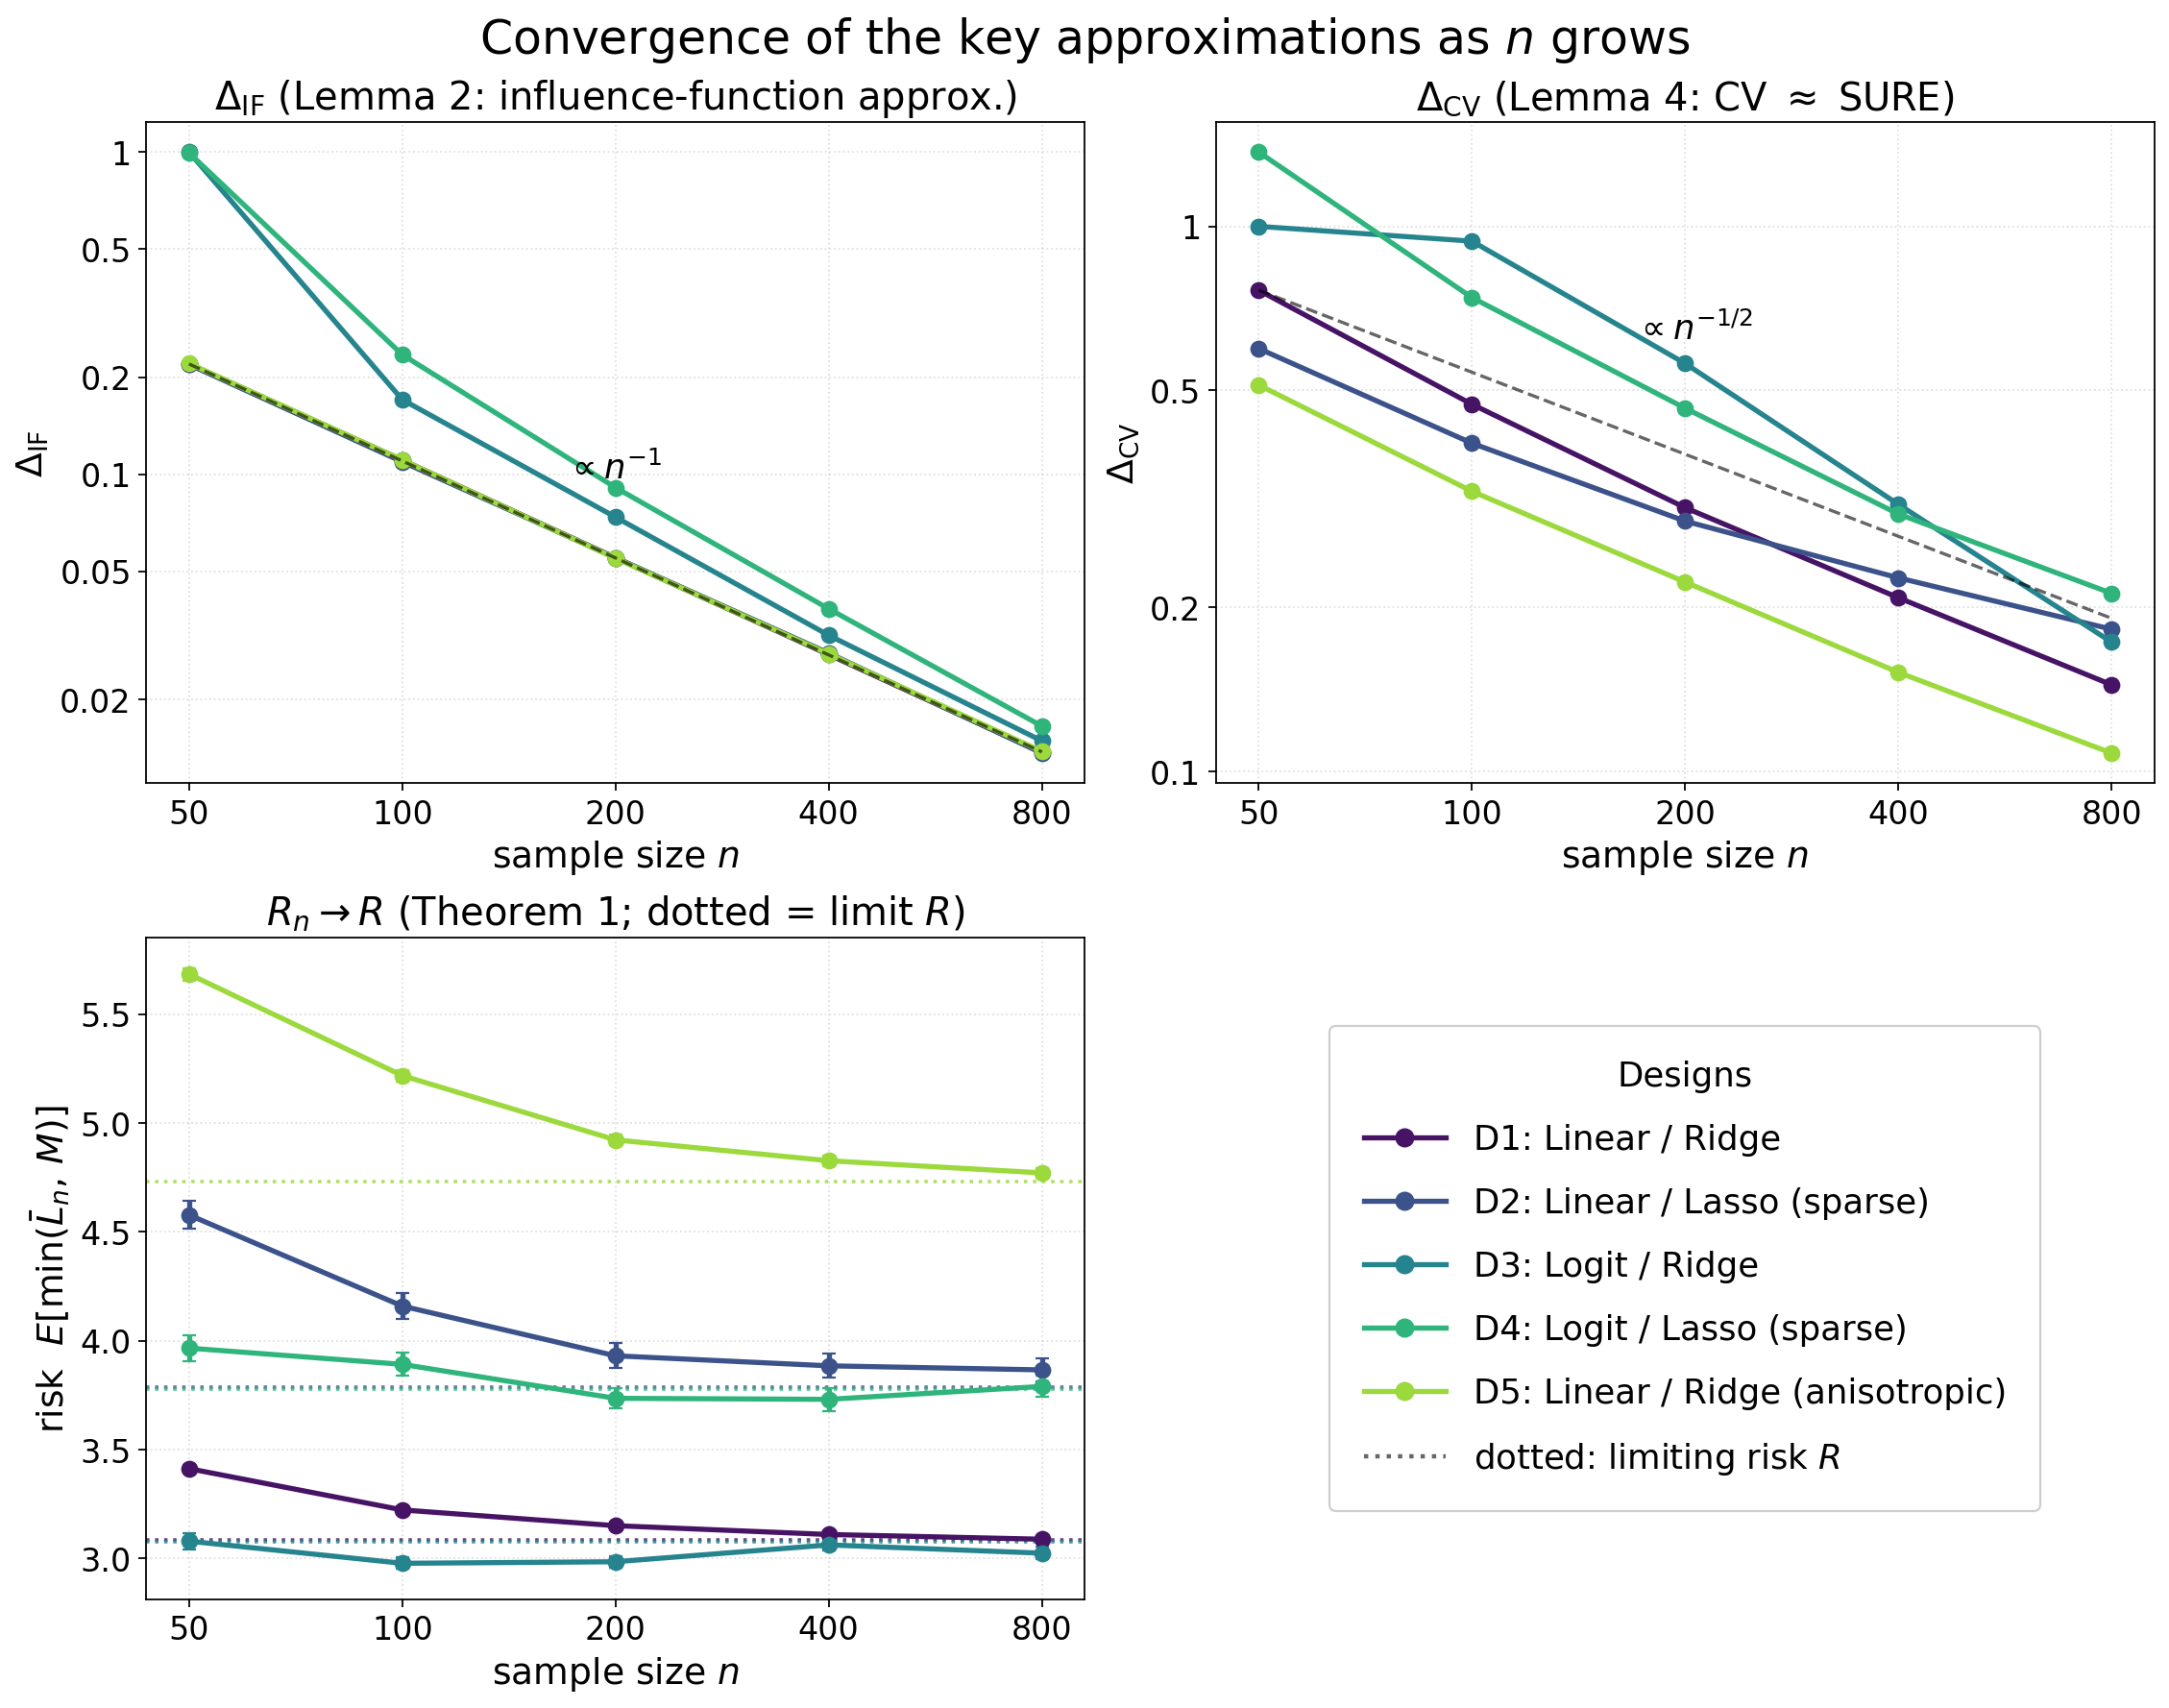

In [5]:
display(Image(os.path.join(OUTDIR, "fig1_convergence.png")))

## 6. Figure 2 — convergence of the risk function

Along a one-dimensional slice $\theta_0=t\,v$, the finite-$n$ risk
$R_n(\theta_0)$ of the CV-tuned linear–Ridge estimator converges to the
SURE-tuned limit $R(\theta_0)$. By $n=200$ the curves are essentially
indistinguishable from the limit — the equivalence is useful at realistic sample
sizes, not only asymptotically.

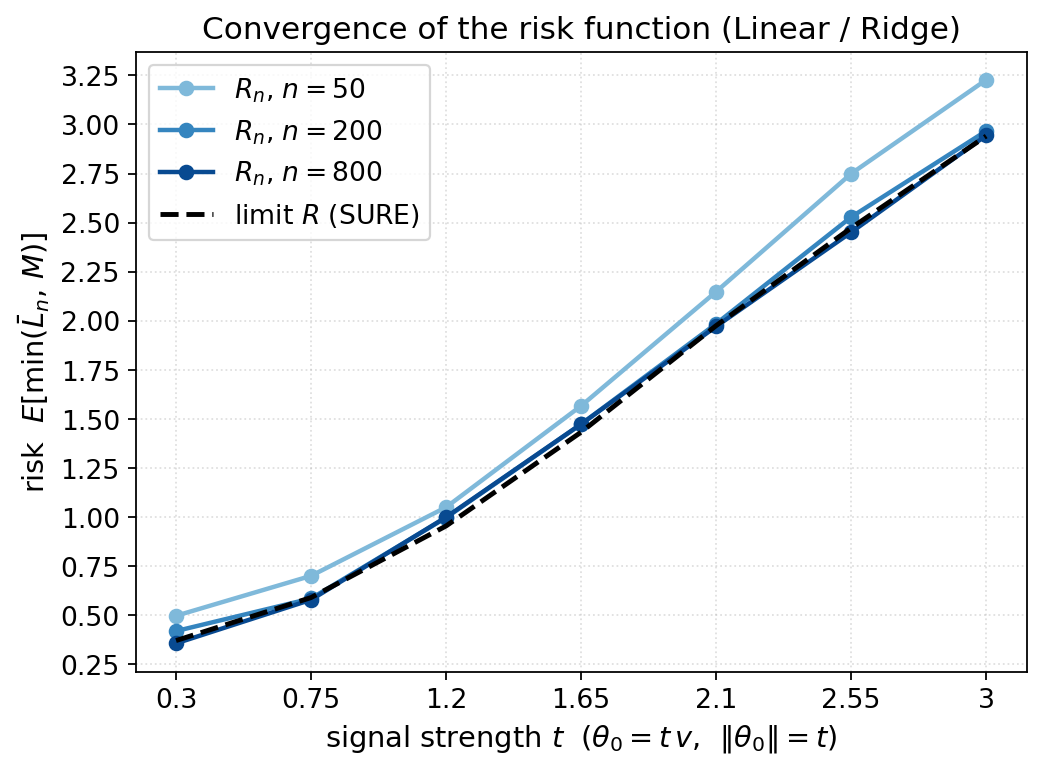

In [6]:
display(Image(os.path.join(OUTDIR, "fig2_riskfunction.png")))

## 7. What the experiments show

* **Lemma 2 (influence-function approx.)** — $\Delta_{\mathrm{IF}}\to0$ at the
  parametric rate $\sim n^{-1}$ for every design; the linearization
  $\hat\theta_n\approx\tilde\theta_n$ is accurate. (Its one large small-sample
  value is logit–Lasso D4 at $n=50$, where the unpenalized MLE is nearly separated
  at $p=10$; it falls quickly as $n$ grows.)
* **Lemma 4 (CV $\approx$ SURE)** — $\Delta_{\mathrm{CV}}\to0$ at $\sim n^{-1/2}$,
  once CV is compared to $SURE$ (which, following the manuscript, carries the
  factor $\tfrac12$; see the normalization note at the top). Recentering at a reference $\lambda$ absorbs the
  $\Omega(n)$ constant $c_n$; we do **not** rescale $CV_n$ by $1/n$, which would
  destroy the $O(1)$ degrees-of-freedom term.
* **Lemma 5 / Theorem 1** — the CV- and SURE-selected tuning agree
  ($\Delta_{\mathrm{tune}}$ a few percent), so the tuned risk $R_n$ converges to the
  limit $R$ ($\Delta_{R}$ small; Figure 2). The tuning gap is largest for the
  **Lasso** designs, whose kinked objective is least smooth, and smallest for the
  anisotropic design **D5** — there $SURE$ is flat near its minimum, so although the
  minimizer is poorly separated the loss is insensitive to the exact $\lambda$.
  Poor separation and large excess loss need not coincide.